<a href="https://colab.research.google.com/github/MadhurJain06/xG-model/blob/code/xg_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn statsmodels


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import os
os.chdir('/content/drive/MyDrive/xg_model')

- Data is in JSON format

In [5]:
# !wget https://github.com/statsbomb/open-data/archive/refs/heads/master.zip
# !unzip master.zip -d data/raw

# Since the data has been downloaded and saved as unziped no need to run it again

## Step-1 :
create one clean csv with 1 row per shot and columns like:

shot_outcome, body_part, shot_type, shot_angle and many such.

## Filter only shot events
I am only considering a model for xG hence other stats are no use for now

In [36]:
import os, json
import pandas as pd
from tqdm import tqdm

events_path = '/content/drive/MyDrive/xg_model/data/raw/open-data-master/data/events/'

all_shots = []

# Loop over all match files
for file in tqdm(os.listdir(events_path)):
    if not file.endswith('.json'):
        continue
    with open(os.path.join(events_path, file), 'r') as f:
        data = json.load(f)
        df = pd.json_normalize(data, sep='_')
        shots = df[df['type_name'] == 'Shot'].copy()
        if not shots.empty:
            all_shots.append(shots)

# Merge all shots
shots = pd.concat(all_shots, ignore_index=True)
print("Total shots:", len(shots))


100%|██████████| 2304/2304 [24:46<00:00,  1.55it/s]


Total shots: 58946


In [37]:
shots.shape

(58946, 149)

### Now extract key columns
pick what's useful

In [38]:
cols = [
    'player_name', 'team_name', 'minute', 'location', 'shot_end_location', 'shot_outcome_name',
    'shot_body_part_name', 'shot_type_name'
]
shot= shots[cols]
shot


,player_name,team_name,minute,location,shot_end_location,shot_outcome_name,shot_body_part_name,shot_type_name
0,Claudia Walker,Everton LFC,3,"[97.0, 43.0]","[100.0, 40.0]",Blocked,Left Foot,Open Play
1,Claudia Walker,Everton LFC,9,"[100.0, 34.0]","[106.0, 35.0]",Blocked,Right Foot,Open Play
2,Inessa Kaagman,Everton LFC,9,"[96.0, 37.0]","[119.0, 45.6, 2.7]",Off T,Left Foot,Open Play
3,Georgia Stanway,Manchester City WFC,13,"[101.0, 54.0]","[120.0, 36.4, 2.0]",Goal,Right Foot,Open Play
4,Chloe Kelly,Everton LFC,14,"[80.0, 38.0]","[116.0, 45.0]",Wayward,Right Foot,Open Play
...,...,...,...,...,...,...,...,...
58941,Patrick Bamford,Crystal Palace,82,"[101.2, 48.8]","[116.5, 39.9, 0.0]",Saved,Left Foot,Open Play
58942,Yohan Cabaye,Crystal Palace,85,"[102.8, 30.7]","[104.3, 48.9]",Wayward,Right Foot,Open Play
58943,James McArthur,Crystal Palace,88,"[93.2, 34.4]","[120.0, 25.6, 2.4]",Off T,Left Foot,Open Play
58944,Yohan Cabaye,Crystal Palace,91,"[103.7, 44.4]","[120.0, 40.4, 6.6]",Off T,Right Foot,Open Play


#### Split the field location from array to x,y

In [39]:
shots['x'] = shots['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else None)
shots['y'] = shots['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else None)


/tmp/ipython-input-3519659719.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  shots['x'] = shots['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else None)
/tmp/ipython-input-3519659719.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  shots['y'] = shots['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else None)


We want a binary label

In [40]:
shots['is_goal'] = (shots['shot_outcome_name'] == 'Goal').astype(int)


/tmp/ipython-input-385301534.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  shots['is_goal'] = (shots['shot_outcome_name'] == 'Goal').astype(int)


Drop the unnecessary columns with nill values

In [41]:
shots = shots.drop(columns=['location','shot_end_location'])
shots = shots.dropna(subset=['x','y'])
shots.head()

,id,index,period,timestamp,minute,second,possession,duration,type_id,type_name,...,goalkeeper_success_in_play,goalkeeper_saved_to_post,goalkeeper_lost_out,goalkeeper_success_out,goalkeeper_penalty_saved_to_post,shot_kick_off,half_end_early_video_end,x,y,is_goal
0,237cf50d-dcd8-4ef0-be6a-19caef9cc3dc,200,1,00:03:10.331,3,10,6,0.643700,16,Shot,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.0,43.0,0
1,ce85277f-166e-45ad-bf86-b04e93f13896,461,1,00:09:06.673,9,6,24,0.724600,16,Shot,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,34.0,0
2,59bee61d-c9d8-4d40-badb-1a9f65367d24,469,1,00:09:09.842,9,9,24,1.424964,16,Shot,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.0,37.0,0
3,e1ac5232-c621-45db-ac33-e4e562a26045,668,1,00:13:44.348,13,44,38,1.133222,16,Shot,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101.0,54.0,1
4,be9bf4db-f539-4c08-be97-6692725bbbab,691,1,00:14:55.496,14,55,40,2.344300,16,Shot,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.0,38.0,0


## Saving the processed dataset of shots

In [42]:
shots.to_csv('/content/drive/MyDrive/xg_model/data/processed/shots_clean.csv',index=False)

Now shot Distance and Shot angle(via coordinates of location)

- Pitch is divided to 120 x 80 units.
- Bottom left corner is the origin, (0,0)
- goal center is at (120,40)
- we consider the posts to be approximately 8 yds hence approx. 8 units tall

In [43]:
# computing shot distance
import numpy as np
goal_x, goal_y = 120,40
shots['shot_distance'] = np.sqrt((goal_x-shots['x'])**2 + (goal_y-shots['y'])**2)

## now computing angles
Consider the 2 posts as pts.

- Left post: (120, 36)

- Right post: (120, 44)

We will calculate angle in radians, between these posts to the player's postion on field

θ=arctan2(A,B)

A: shotDistance*goalwidth
B: shotDistance^2 - (goalwidth/2)^2: would be easier if we use vectors

In [44]:
# computing via vectors
left_post = np.array([120, 36])
right_post = np.array([120, 44])
angles =[]

for _, row in shots.iterrows():
  shot_loc = np.array([row['x'], row['y']])
  # vectors from shot to posts
  vec_l = left_post- shot_loc
  vec_r = right_post- shot_loc
  # Get angle using dot product formula
  dot = np.dot(vec_l, vec_r)
  mag = np.linalg.norm(vec_l) * np.linalg.norm(vec_r)
  angle = np.arccos(dot / mag)
  angles.append(angle)


shots['shot_angle'] = angles

In [45]:
shots['shot_angle_deg'] = np.degrees(shots['shot_angle'])

In [46]:
shots[['x','y','shot_distance','shot_angle_deg']].head()

,x,y,shot_distance,shot_angle_deg
0,97.0,43.0,23.194827,19.417066
1,100.0,34.0,20.880613,20.854458
2,96.0,37.0,24.186773,18.646149
3,101.0,54.0,23.600847,15.693302
4,80.0,38.0,40.049969,11.393171


In [47]:
shots.to_csv('/content/drive/MyDrive/xg_model/data/processed/shots_features.csv', index=False)

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
# load dataset
path = '/content/drive/MyDrive/xg_model/data/processed/shots_features.csv'
shots = pd.read_csv(path)
shots.head()

/tmp/ipython-input-3694529803.py:3: DtypeWarning: Columns (145) have mixed types. Specify dtype option on import or set low_memory=False.
  shots = pd.read_csv(path)


,id,index,period,timestamp,minute,second,possession,duration,type_id,type_name,...,goalkeeper_success_out,goalkeeper_penalty_saved_to_post,shot_kick_off,half_end_early_video_end,x,y,is_goal,shot_distance,shot_angle,shot_angle_deg
0,237cf50d-dcd8-4ef0-be6a-19caef9cc3dc,200,1,00:03:10.331,3,10,6,0.643700,16,Shot,...,NaN,NaN,NaN,NaN,97.0,43.0,0,23.194827,0.338892,19.417066
1,ce85277f-166e-45ad-bf86-b04e93f13896,461,1,00:09:06.673,9,6,24,0.724600,16,Shot,...,NaN,NaN,NaN,NaN,100.0,34.0,0,20.880613,0.363979,20.854458
2,59bee61d-c9d8-4d40-badb-1a9f65367d24,469,1,00:09:09.842,9,9,24,1.424964,16,Shot,...,NaN,NaN,NaN,NaN,96.0,37.0,0,24.186773,0.325437,18.646149
3,e1ac5232-c621-45db-ac33-e4e562a26045,668,1,00:13:44.348,13,44,38,1.133222,16,Shot,...,NaN,NaN,NaN,NaN,101.0,54.0,1,23.600847,0.273900,15.693302
4,be9bf4db-f539-4c08-be97-6692725bbbab,691,1,00:14:55.496,14,55,40,2.344300,16,Shot,...,NaN,NaN,NaN,NaN,80.0,38.0,0,40.049969,0.198848,11.393171


We’ll use only a few clean features for now:

- shot_distance
- shot_angle

maybe shot_body_part_name (later)

In [50]:
X = shots[['shot_distance', 'shot_angle']]
y = shots['is_goal']
shots.shape

(58946, 153)

80-20 Split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42, stratify=y
)

since, units of distance and angles are different, we would have to scale them to implement logistic regression.

In [52]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [53]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced')

## Predicting Probability of Goal

that is xG itself. (expected-Goals

In [54]:
y_pred_prob = model.predict_proba(X_test_scaled)[:,1]
shots.loc[y_test.index, 'xG'] = y_pred_prob


## Evaluating Performance

In [55]:
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC AUC:", roc_auc)


ROC AUC: 0.747725248082765


Accuracy: 0.6820186598812553
Precision: 0.20892351274787535
Recall: 0.6897895557287607
ROC AUC: 0.747725248082765


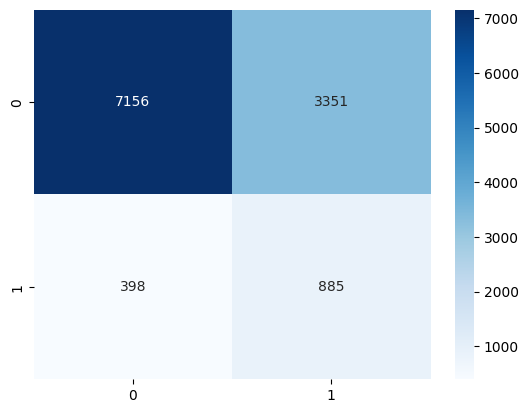

In [56]:
y_pred_prob = model.predict_proba(X_test_scaled)[:,1]
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.show()


Changing the goal-probability cutoff:

Right now, we are classifying “goal” if prob ≥ 0.5, but in real xG, most shots are <0.3.

In [57]:
for t in [0.1, 0.2, 0.3]:
    y_pred = (y_pred_prob >= t).astype(int)
    print(f"Threshold={t}")
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print()


Threshold=0.1
Precision: 0.10963026655202064
Recall: 0.9937646141855028

Threshold=0.2
Precision: 0.1221839645843581
Recall: 0.9680436477007015

Threshold=0.3
Precision: 0.14953033764914953
Recall: 0.9181605611847233



In [58]:
shots['shot_body_part_name'].fillna('Unknown', inplace=True)
shots = pd.get_dummies(shots, columns=['shot_body_part_name'], drop_first=True)


/tmp/ipython-input-1431437883.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  shots['shot_body_part_name'].fillna('Unknown', inplace=True)


In [59]:
shots.head()

,id,index,period,timestamp,minute,second,possession,duration,type_id,type_name,...,x,y,is_goal,shot_distance,shot_angle,shot_angle_deg,xG,shot_body_part_name_Left Foot,shot_body_part_name_Other,shot_body_part_name_Right Foot
0,237cf50d-dcd8-4ef0-be6a-19caef9cc3dc,200,1,00:03:10.331,3,10,6,0.643700,16,Shot,...,97.0,43.0,0,23.194827,0.338892,19.417066,NaN,True,False,False
1,ce85277f-166e-45ad-bf86-b04e93f13896,461,1,00:09:06.673,9,6,24,0.724600,16,Shot,...,100.0,34.0,0,20.880613,0.363979,20.854458,NaN,False,False,True
2,59bee61d-c9d8-4d40-badb-1a9f65367d24,469,1,00:09:09.842,9,9,24,1.424964,16,Shot,...,96.0,37.0,0,24.186773,0.325437,18.646149,0.292362,True,False,False
3,e1ac5232-c621-45db-ac33-e4e562a26045,668,1,00:13:44.348,13,44,38,1.133222,16,Shot,...,101.0,54.0,1,23.600847,0.273900,15.693302,NaN,False,False,True
4,be9bf4db-f539-4c08-be97-6692725bbbab,691,1,00:14:55.496,14,55,40,2.344300,16,Shot,...,80.0,38.0,0,40.049969,0.198848,11.393171,NaN,False,False,True


In [60]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,  # ensure convergence on big data, usually default is 100
    random_state=42
)


Training over further scaled features now

In [61]:
from sklearn.preprocessing import StandardScaler

# Select features
X = shots[['shot_distance', 'shot_angle']]
y = shots['is_goal']

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit
model.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

predicting xG's as earlier

In [62]:
y_pred_prob = model.predict_proba(X_test_scaled)[:,1]
shots.loc[y_test.index, 'xG'] = y_pred_prob


In [67]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score

y_pred = (y_pred_prob >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))


Accuracy: 0.6820186598812553
Precision: 0.20892351274787535
Recall: 0.6897895557287607
ROC AUC: 0.747725248082765


so now we need to fix the threshhold, since most of the goals are scored with xG lower than .1, earlier threshold was .5

The xG will give the chances how much possibility is to score but to predict we have an absolute answer so we take xG threshold for goal and no goal :.1

In [68]:
y_pred = (y_pred_prob >= 0.1).astype(int)


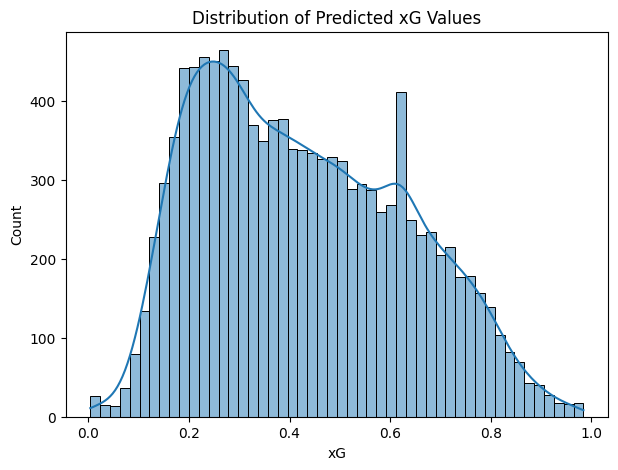

In [69]:
#Lets check again the xG
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.histplot(y_pred_prob, bins=50, kde=True)
plt.title("Distribution of Predicted xG Values")
plt.xlabel("xG")
plt.show()


## Choosing Caliberation method

since the data is quite large, we will use isotonic regression method

We split train set into:

- Training the logistic regression

- Calibration set

In [81]:
from sklearn.model_selection import train_test_split

# Split train into model-train and calibration-train
X_model_train, X_calib, y_model_train, y_calib = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)


Training the base logistic regression

In [82]:
from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
base_model.fit(X_model_train, y_model_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

Caliberation:

In [83]:
from sklearn.calibration import CalibratedClassifierCV

calib_model = CalibratedClassifierCV(base_model, method='isotonic', cv='prefit')
calib_model.fit(X_calib, y_calib)


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


CalibratedClassifierCV(cv='prefit',
                       estimator=LogisticRegression(class_weight='balanced',
                                                    max_iter=1000,
                                                    random_state=42),
                       method='isotonic')

Now the calliberative model should give calliberated probabilities

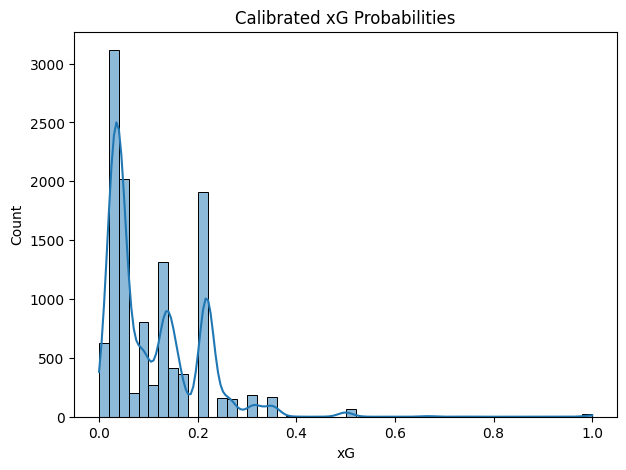

In [85]:
#Test calib. probabilities
y_calib_pred_prob = calib_model.predict_proba(X_test_scaled)[:,1]

# Optional: histogram to see distribution

plt.figure(figsize=(7,5))
sns.histplot(y_calib_pred_prob, bins=50, kde=True)
plt.title("Calibrated xG Probabilities")
plt.xlabel("xG")
plt.show()


As we see, most of the goals are scored in range less than .2xG, and some really high prb. chances near .5,.6: Quite realistic !

## Evaluate Caliberated model

In [86]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_calib_pred_prob)
print("Brier Score:", brier)


Brier Score: 0.08761024539659877


Lower Brier Score: Probabs. are more accurate,

So now, .1xG really means it has 10% chance

Compute Caliberation curve

In [89]:
# y_test = true labels, y_calib_pred_prob = predicted probabilities
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_calib_pred_prob, n_bins=10)


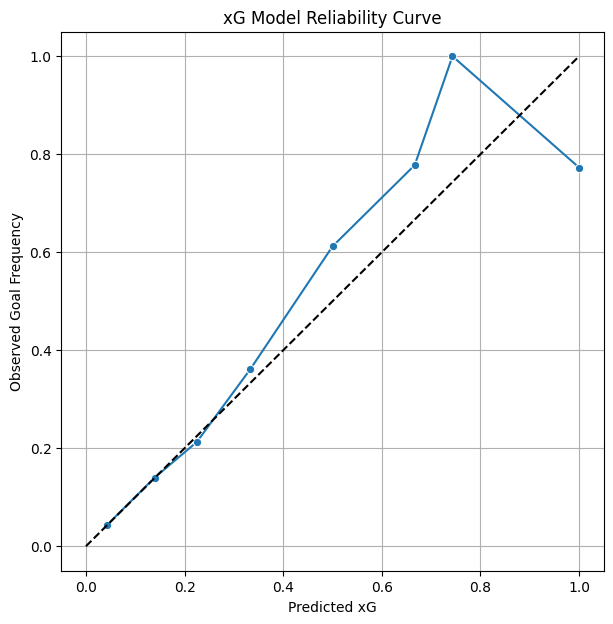

In [91]:
#plot
plt.figure(figsize=(7,7))
sns.lineplot(x=prob_pred, y=prob_true, marker='o')
plt.plot([0, 1], [0, 1], 'k--')  # perfect calibration line
plt.title("xG Model Reliability Curve")
plt.xlabel("Predicted xG")
plt.ylabel("Observed Goal Frequency")
plt.grid(True)
plt.show()


Here:
- Diagonal line = perfect match (predicted = actual)

- Points above line → model underestimates goals

- Points below line → model overestimates goals

In [92]:
# shots should already have 'player_name' and 'xG'
player_xg = shots.groupby('player_name')['xG'].sum().reset_index()
player_xg = player_xg.sort_values(by='xG', ascending=False)
player_xg.head(10)  # top 10 players by expected goals


,player_name,xG
2481,Lionel Andrés Messi Cuccittini,131.589142
2571,Luis Alberto Suárez Díaz,60.696854
3116,Neymar da Silva Santos Junior,34.326978
4165,Vivianne Miedema,31.275535
347,Antoine Griezmann,27.240346
772,Cristiano Ronaldo dos Santos Aveiro,25.480213
2365,Kylian Mbappé Lottin,24.081495
1579,Harry Kane,20.067760
3607,Romelu Lukaku Menama,18.931450
1076,Ellen White,16.827470


In [93]:
player_goals = shots.groupby('player_name')['is_goal'].sum().reset_index()
player_stats = player_xg.merge(player_goals, on='player_name')
player_stats.rename(columns={'is_goal':'actual_goals'}, inplace=True)
player_stats['xG_diff'] = player_stats['xG'] - player_stats['actual_goals']
player_stats.head(10)



,player_name,xG,actual_goals,xG_diff
0,Lionel Andrés Messi Cuccittini,131.589142,256,-124.410858
1,Luis Alberto Suárez Díaz,60.696854,112,-51.303146
2,Neymar da Silva Santos Junior,34.326978,83,-48.673022
3,Vivianne Miedema,31.275535,57,-25.724465
4,Antoine Griezmann,27.240346,44,-16.759654
5,Cristiano Ronaldo dos Santos Aveiro,25.480213,48,-22.519787
6,Kylian Mbappé Lottin,24.081495,58,-33.918505
7,Harry Kane,20.067760,32,-11.932240
8,Romelu Lukaku Menama,18.931450,22,-3.068550
9,Ellen White,16.827470,25,-8.172530


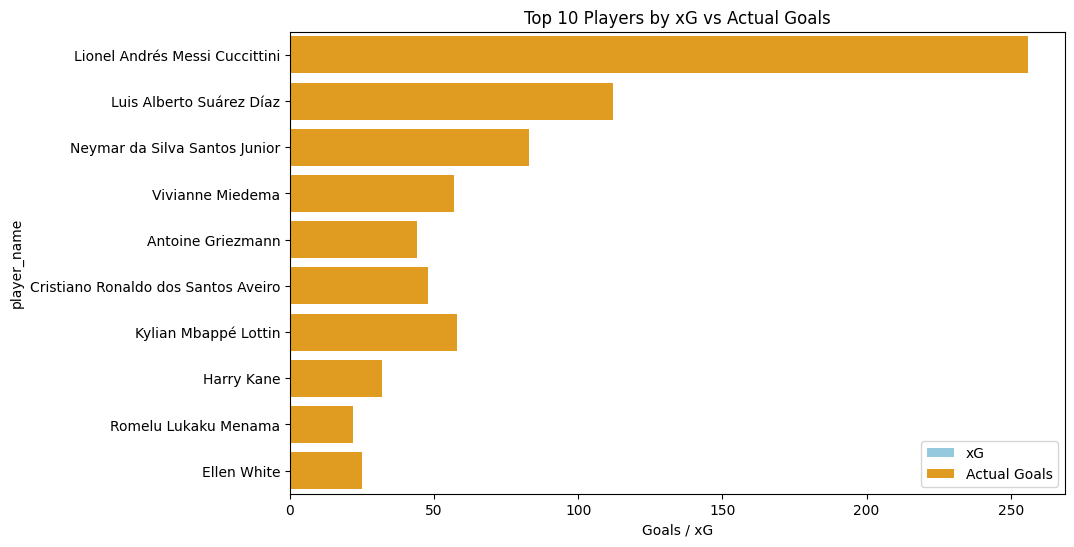

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

top10 = player_stats.head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='xG', y='player_name', data=top10, color='skyblue', label='xG')
sns.barplot(x='actual_goals', y='player_name', data=top10, color='orange', label='Actual Goals')
plt.xlabel("Goals / xG")
plt.title("Top 10 Players by xG vs Actual Goals")
plt.legend()
plt.show()


# xG Scatter plot

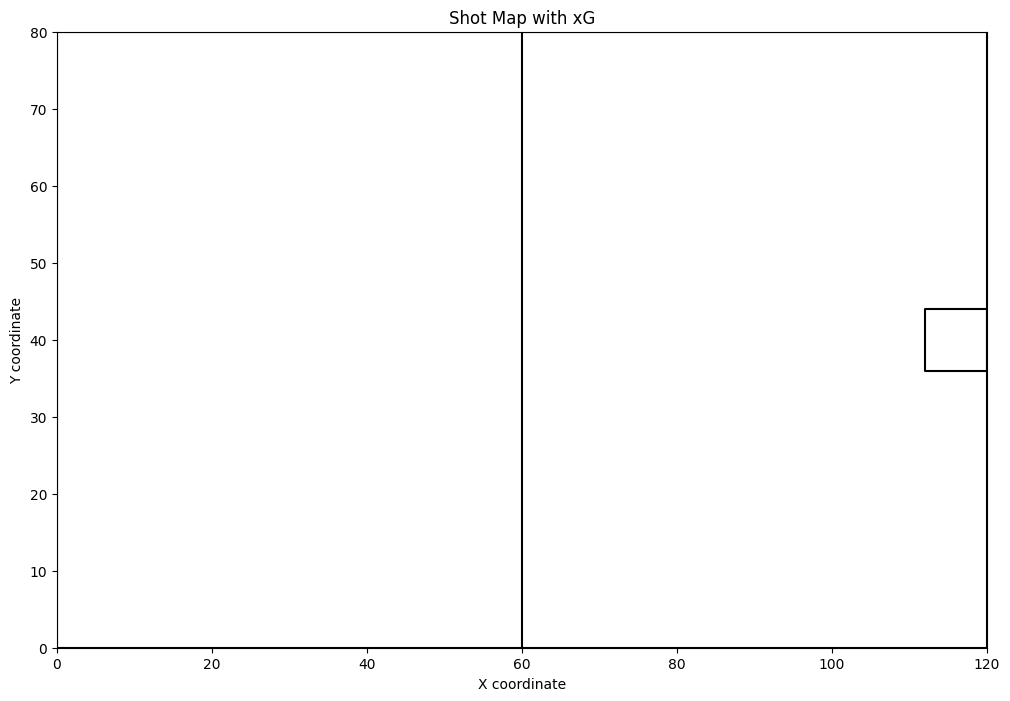

In [95]:
import matplotlib.pyplot as plt

def draw_pitch(ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12,8))

    # Pitch Outline
    ax.plot([0,120,120,0,0],[0,0,80,80,0], color="black")

    # Goal box
    ax.plot([120,120,112,112,120],[36,44,44,36,36], color="black")

    # Halfway line
    ax.plot([60,60],[0,80], color="black")

    ax.set_xlim(0,120)
    ax.set_ylim(0,80)
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.set_title("Shot Map with xG")
    return ax

ax = draw_pitch()
plt.show()


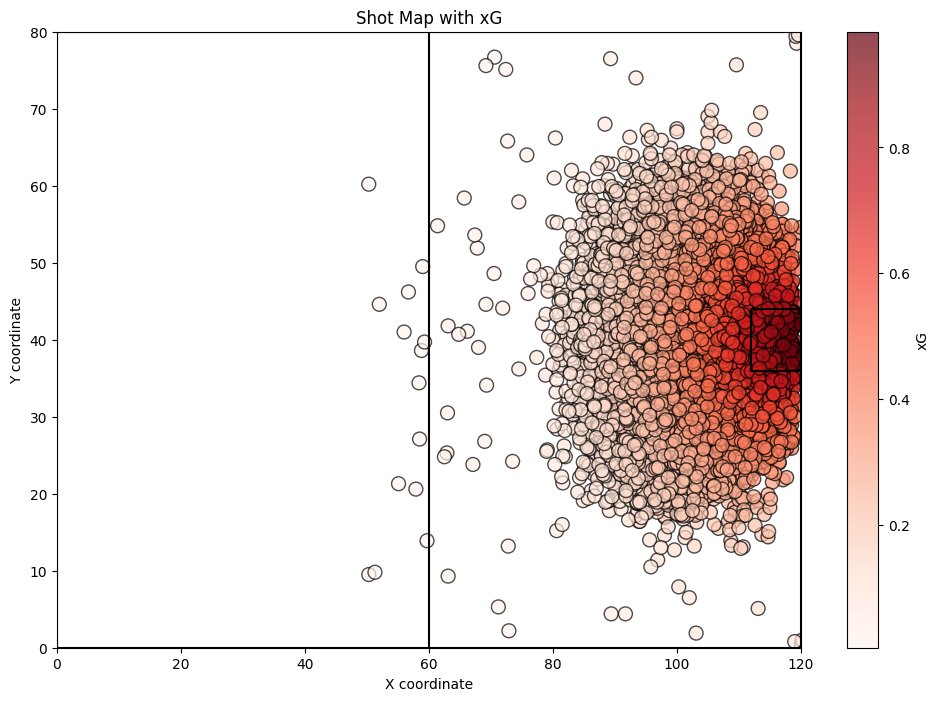

In [96]:
# Only shots with xG column (after calibration)
shots_plot = shots.dropna(subset=['xG'])

ax = draw_pitch()
sc = ax.scatter(
    shots_plot['x'],
    shots_plot['y'],
    c=shots_plot['xG'],  # color by xG
    cmap='Reds',          # higher xG = deeper red
    s=100,                # marker size
    alpha=0.7,
    edgecolors='black'
)
plt.colorbar(sc, label="xG")
plt.show()


RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

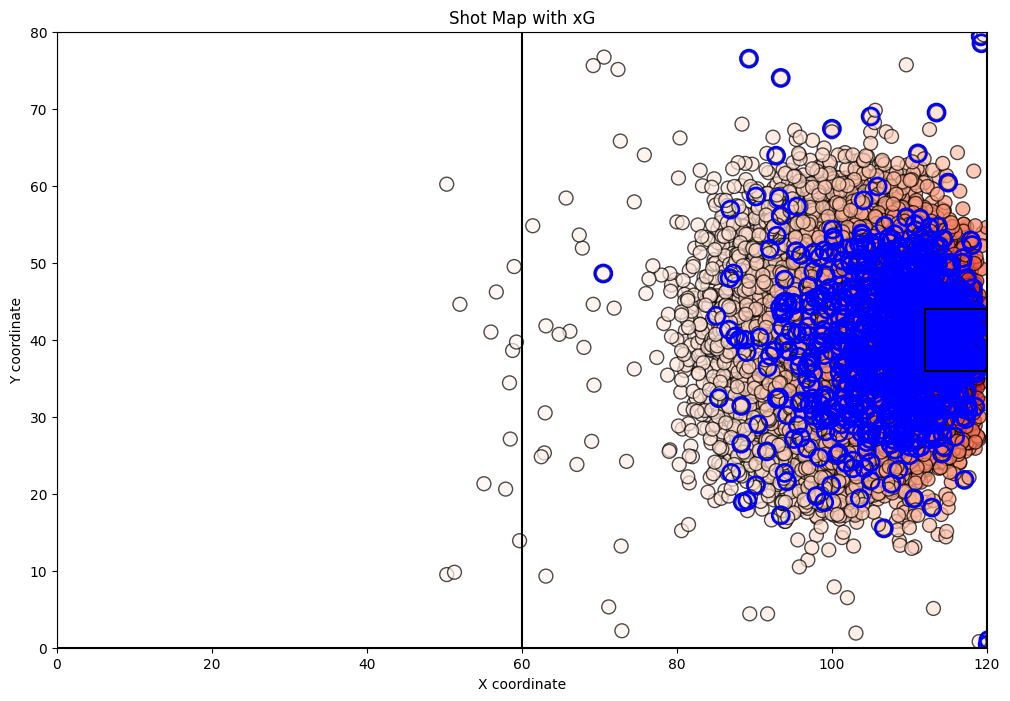

In [98]:
ax = draw_pitch()
ax.scatter(
    shots_plot['x'],
    shots_plot['y'],
    c=shots_plot['xG'],
    cmap='Reds',
    s=100, alpha=0.7, edgecolors='black'
)
# Overlay actual goals
goals = shots_plot[shots_plot['is_goal']==1]
ax.scatter(
    goals['x'],
    goals['y'],
    facecolors='none', edgecolors='blue',
    s=150, linewidth=2, label='Goal'
)
plt.colorbar(label="xG")
plt.legend()
plt.show()
